In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

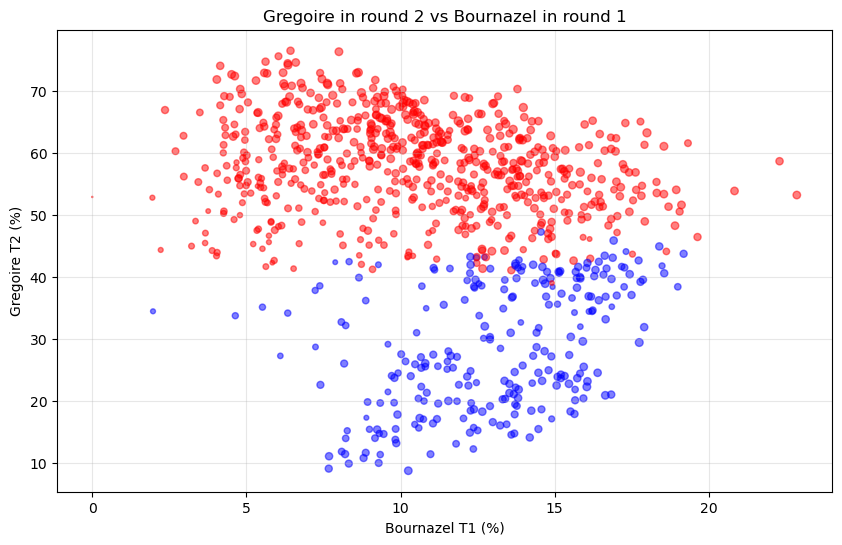

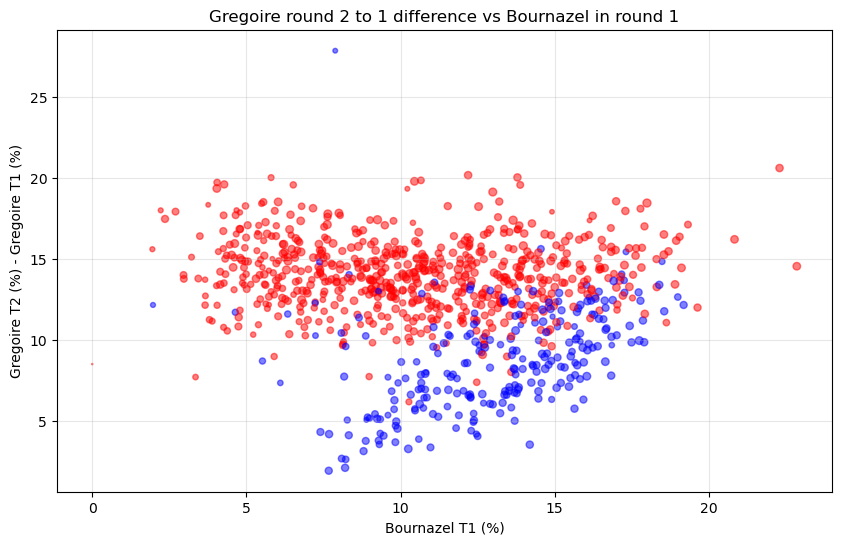

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
df1 = pd.read_csv('municipales26_tour1_paris.csv', encoding='utf-8', sep = ';')
df2 = pd.read_csv('municipales26_tour2_paris.csv', encoding='utf-8', sep = ';')
# remove unwanted spaces from column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

col_x = '% Voix/exprimes 6'
col_y = '% Voix/exprimes 1'

# plot colors according to voting behaviour in round 1
gregoire_round1 = pd.to_numeric(df1['% Voix/exprimes 3'].astype(str).str.replace(',', '.'), errors='coerce')
dati_round1 = pd.to_numeric(df1['% Voix/exprimes 7'].astype(str).str.replace(',', '.'), errors='coerce')

sizes = pd.to_numeric(df1['Votants'], errors='coerce').fillna(0)
sizes = sizes/np.max(sizes)
#modify dot sizes by number of registered voters
scale_factor = 35

colors = np.where(gregoire_round1 > dati_round1, 'red', 'blue')

plt.figure(figsize=(10, 6))
plt.title('Gregoire in round 2 vs Bournazel in round 1')
plt.scatter(df1[col_x], df2[col_y], c = colors, s = sizes*scale_factor,alpha=0.5)
plt.xlabel(f'Bournazel T1 (%)')
plt.ylabel(f'Gregoire T2 (%)')
plt.grid(True, alpha=0.3)
plt.show()

# now plot the percent difference for Gregoire in the second round. for a finer study should take abstension into account. 
# but this is ok to that a first look at

plt.figure(figsize=(10, 6))
plt.title('Gregoire round 2 to 1 difference vs Bournazel in round 1')
plt.scatter(df1[col_x], df2[col_y] - gregoire_round1, c = colors, s = sizes*scale_factor,alpha=0.5)
plt.xlabel(f'Bournazel T1 (%)')
plt.ylabel(f'Gregoire T2 (%) - Gregoire T1 (%)')
plt.grid(True, alpha=0.3)
plt.show()


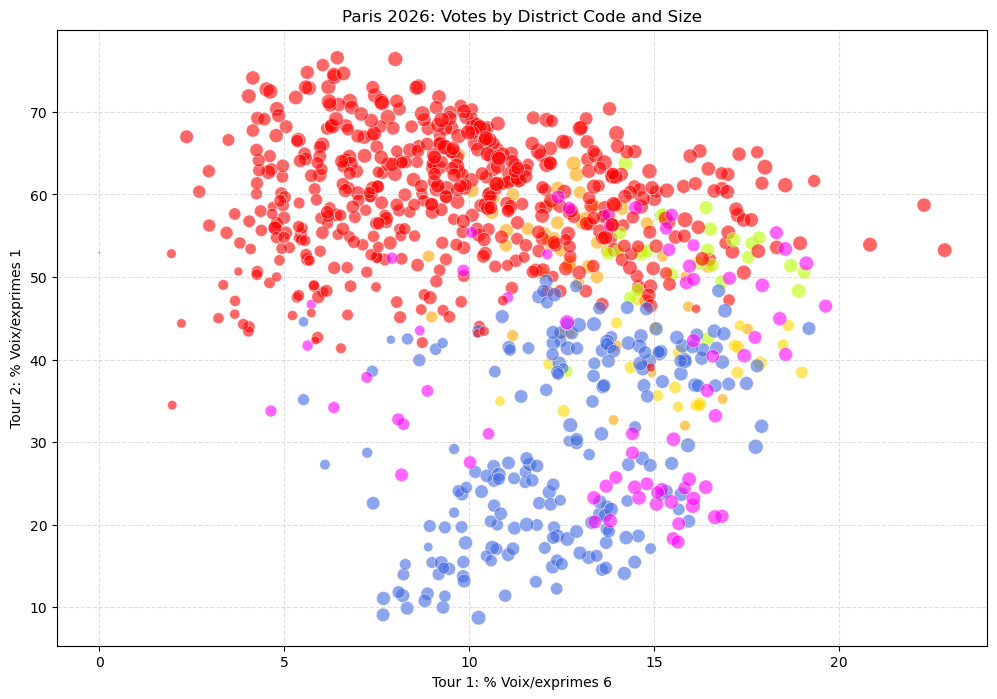

In [39]:

# 1. Load data
df1 = pd.read_csv('municipales26_tour1_paris.csv', sep=';')
df2 = pd.read_csv('municipales26_tour2_paris.csv', sep=';')

# Clean column names
df1.columns = df1.columns.str.strip().str.replace('é', 'e')
df2.columns = df2.columns.str.strip().str.replace('é', 'e')

try:
    # Identify X, Y, and Size columns
    col_x = '% Voix/exprimes 6'
    col_y = '% Voix/exprimes 1'
    
    # Convert data to numeric
    x_val = pd.to_numeric(df1[col_x].astype(str).str.replace(',', '.'), errors='coerce')
    y_val = pd.to_numeric(df2[col_y].astype(str).str.replace(',', '.'), errors='coerce')
    voters_size = pd.to_numeric(df1['Votants'], errors='coerce').fillna(0) * 0.1

    # 2. Process 'Code BV' for coloring
    # Round down to the hundreds (e.g., 672 -> 600)
    bv_numeric = pd.to_numeric(df1['Code BV'], errors='coerce').fillna(0)
    bv_hundreds = (bv_numeric // 100) * 100

    def assign_color(val):
        if val == 600: return '#FFD700'  # Gold (Yellow shade)
        elif val == 900: return "#BBFF00" # Yellow
        elif val in [100, 200, 300, 400]: return 'orange'
        elif val in [700, 800, 1500, 1600]: return 'royalblue'
        elif val == 1700: return 'magenta'
        else: return 'red' # Default shade of blue

    marker_colors = bv_hundreds.apply(assign_color)

    # 3. Plot
    plt.figure(figsize=(12, 8))
    plt.scatter(
        x_val, 
        y_val, 
        s=voters_size, 
        c=marker_colors, 
        alpha=0.6, 
        edgecolors='white', 
        linewidth=0.5
    )

    plt.xlabel(f"Tour 1: {col_x}")
    plt.ylabel(f"Tour 2: {col_y}")
    plt.title("Paris 2026: Votes by District Code and Size")
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.show()

except Exception as e:
    print(f"Error encountered: {e}")